In [ ]:
# ==============================================================================
# CELL 1: Environment Setup & Baseline Data Ingestion
# ==============================================================================
!pip install -q scikit-learn imbalanced-learn pandas numpy

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, classification_report
from imblearn.over_sampling import SMOTE

# Load dataset (upload your CSV or place it in the Colab file browser)
try:
    df = pd.read_csv("mental_health_burnout_tech_2026.csv")
except FileNotFoundError:
    print("[!] Local CSV not found. Generating sample data matching paper's 68:32 distribution...")
    np.random.seed(42)
    n = 10000
    df = pd.DataFrame({
        "job_role": np.random.choice(["Software Engineer", "DevOps", "Data Scientist", "Product Manager"], n),
        "country": np.random.choice(["United States", "Germany", "India", "United Kingdom"], n),
        "work_environment": np.random.choice(["Remote", "Hybrid", "On-site"], n),
        "work_hours_per_week": np.random.normal(45, 10, n).clip(20, 80),
        "sleep_hours_per_night": np.random.normal(6.5, 1.2, n).clip(3, 10),
        "meetings_per_day": np.random.poisson(4, n).clip(0, 12),
        "stress_score": np.random.randint(1, 11, n),
        "job_burnout_score": np.random.randint(1, 11, n),
        "depression_score": np.random.randint(0, 28, n),
        "anxiety_score": np.random.randint(0, 22, n),
        "job_satisfaction_score": np.random.randint(1, 11, n),
        "salary_usd": np.random.normal(110000, 30000, n).clip(35000, 250000),
        "job_change_intention": np.random.choice([0, 1], p=[0.68, 0.32], size=n)
    })

target_col = "job_change_intention"
X = df.drop(columns=[target_col])
y = df[target_col]

# One-hot encoding for standard Scikit-Learn tree models
X_encoded = pd.get_dummies(X, drop_first=True)

# 80/20 stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.20, stratify=y, random_state=42
)

print(f"Dataset Shape: {X_encoded.shape}")
print(f"Class Ratio (0: Stay, 1: Leave): {np.bincount(y) / len(y)}")

Dataset Shape: (100000, 78)
Class Ratio (0: Stay, 1: Leave): [0.67998 0.32002]


In [ ]:
# ==============================================================================
# CELL 2: Paper Scenario 1 — Base Models (Default Hyperparameters, Threshold 0.5)
# ==============================================================================
# 1. Baseline Random Forest
rf_base = RandomForestClassifier(n_estimators=100, random_state=42)
rf_base.fit(X_train, y_train)

rf_base_preds = rf_base.predict(X_test)
rf_base_probs = rf_base.predict_proba(X_test)[:, 1]

print("--- BASE RANDOM FOREST (Paper Scenario 1) ---")
print(f"Accuracy:  {accuracy_score(y_test, rf_base_preds) * 100:.2f}%")
print(f"F1-Score:  {f1_score(y_test, rf_base_preds) * 100:.2f}%")
print(f"ROC-AUC:   {roc_auc_score(y_test, rf_base_probs):.4f}")
print("Confusion Matrix:\n", confusion_matrix(y_test, rf_base_preds))

# 2. Baseline HistGradientBoosting
hist_base = HistGradientBoostingClassifier(random_state=42)
hist_base.fit(X_train, y_train)

hist_base_preds = hist_base.predict(X_test)
hist_base_probs = hist_base.predict_proba(X_test)[:, 1]

print("\n--- BASE HIST GRADIENT BOOSTING (Paper Scenario 1) ---")
print(f"Accuracy:  {accuracy_score(y_test, hist_base_preds) * 100:.2f}%")
print(f"F1-Score:  {f1_score(y_test, hist_base_preds) * 100:.2f}%")
print(f"ROC-AUC:   {roc_auc_score(y_test, hist_base_probs):.4f}")
print("Confusion Matrix:\n", confusion_matrix(y_test, hist_base_preds))

--- BASE RANDOM FOREST (Paper Scenario 1) ---
Accuracy:  68.52%
F1-Score:  25.51%
ROC-AUC:   0.6680
Confusion Matrix:
 [[12625   975]
 [ 5322  1078]]

--- BASE HIST GRADIENT BOOSTING (Paper Scenario 1) ---
Accuracy:  69.25%
F1-Score:  27.90%
ROC-AUC:   0.6817
Confusion Matrix:
 [[12660   940]
 [ 5210  1190]]


In [ ]:
# ==============================================================================
# CELL 3: Paper Scenario 2 & 3 — SMOTE Resampling Pipeline
# ==============================================================================
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# 1. SMOTE Random Forest
rf_smote = RandomForestClassifier(n_estimators=100, random_state=42)
rf_smote.fit(X_train_smote, y_train_smote)

rf_smote_preds = rf_smote.predict(X_test)
rf_smote_probs = rf_smote.predict_proba(X_test)[:, 1]

print("--- SMOTE RANDOM FOREST (Paper Scenario 2) ---")
print(f"Accuracy:  {accuracy_score(y_test, rf_smote_preds) * 100:.2f}%")
print(f"F1-Score:  {f1_score(y_test, rf_smote_preds) * 100:.2f}%")
print(f"ROC-AUC:   {roc_auc_score(y_test, rf_smote_probs):.4f}")

# 2. SMOTE HistGradientBoosting (Paper's peak minority-class detector)
hist_smote = HistGradientBoostingClassifier(random_state=42)
hist_smote.fit(X_train_smote, y_train_smote)

hist_smote_preds = hist_smote.predict(X_test)
hist_smote_probs = hist_smote.predict_proba(X_test)[:, 1]

print("\n--- SMOTE HIST GRADIENT BOOSTING (Paper Scenario 2/3) ---")
print(f"Accuracy:  {accuracy_score(y_test, hist_smote_preds) * 100:.2f}%")
print(f"F1-Score:  {f1_score(y_test, hist_smote_preds) * 100:.2f}%")
print(f"ROC-AUC:   {roc_auc_score(y_test, hist_smote_probs):.4f}")
print("Confusion Matrix:\n", confusion_matrix(y_test, hist_smote_preds))

--- SMOTE RANDOM FOREST (Paper Scenario 2) ---
Accuracy:  67.30%
F1-Score:  35.87%
ROC-AUC:   0.6592

--- SMOTE HIST GRADIENT BOOSTING (Paper Scenario 2/3) ---
Accuracy:  68.98%
F1-Score:  32.66%
ROC-AUC:   0.6782
Confusion Matrix:
 [[12293  1307]
 [ 4896  1504]]


#After improvement

In [ ]:
# ==============================================================================
# CELL 1: Setup, Feature Engineering & Dynamic Column Detection
# ==============================================================================
!pip install -q scikit-learn optuna joblib pandas numpy

import joblib
import numpy as np
import pandas as pd
import optuna
from google.colab import files
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report

optuna.logging.set_verbosity(optuna.logging.WARNING)

def prepare_features(data: pd.DataFrame) -> pd.DataFrame:
    d = data.copy()
    if "work_hours_per_week" in d.columns and "sleep_hours_per_night" in d.columns:
        d["work_hours_to_sleep_ratio"] = d["work_hours_per_week"] / (d["sleep_hours_per_night"] * 7 + 1e-5)

    mental_components = ["stress_score", "job_burnout_score", "depression_score", "anxiety_score"]
    existing = [c for c in mental_components if c in d.columns]
    if existing:
        d["total_mental_load"] = d[existing].sum(axis=1)
    return d

try:
    df_raw = pd.read_csv("mental_health_burnout_tech_2026.csv")
except FileNotFoundError:
    print("Dataset not found. Please upload mental_health_burnout_tech_workers.csv")
    raise

df_enhanced = prepare_features(df_raw)

target_col = "job_change_intention"

# FIX: Dynamically detect ALL categorical/string columns to prevent ValueError
cat_cols = df_enhanced.select_dtypes(include=['object', 'category']).columns.tolist()
if target_col in cat_cols:
    cat_cols.remove(target_col)

num_cols = [c for c in df_enhanced.columns if c not in cat_cols + [target_col]]

X = df_enhanced[cat_cols + num_cols]
y = df_enhanced[target_col]

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.1765, stratify=y_train_val, random_state=42
)

# Pipeline will now safely route ALL text columns through OneHotEncoder
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols),
        ("num", "passthrough", num_cols),
    ]
)

print(f"Categorical features detected: {cat_cols}")
print(f"Dataset split -> Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")

Categorical features detected: ['gender', 'country', 'job_role', 'seniority_level', 'company_size', 'industry', 'work_mode', 'phq9_category', 'gad7_category', 'burnout_level']
Dataset split -> Train: 69997, Val: 15003, Test: 15000


In [ ]:
# ==============================================================================
# CELL 2: Optuna Bayesian Hyperparameter Optimization (RF & HistGB)
# ==============================================================================
# 1. Optimize HistGradientBoosting
def objective_hist(trial):
    params = {
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "max_iter": trial.suggest_int("max_iter", 100, 300),
        "max_leaf_nodes": trial.suggest_int("max_leaf_nodes", 15, 63),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 10, 50),
        "l2_regularization": trial.suggest_float("l2_regularization", 1e-4, 10.0, log=True),
        "class_weight": "balanced",
        "random_state": 42
    }

    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    scores = []

    for tr_idx, va_idx in cv.split(X_train, y_train):
        pipe = Pipeline([
            ("prep", preprocessor),
            ("clf", HistGradientBoostingClassifier(**params))
        ])
        pipe.fit(X_train.iloc[tr_idx], y_train.iloc[tr_idx])
        preds = pipe.predict(X_train.iloc[va_idx])
        scores.append(f1_score(y_train.iloc[va_idx], preds))

    return np.mean(scores)

print("Tuning HistGradientBoosting with Optuna...")
study_hist = optuna.create_study(direction="maximize")
study_hist.optimize(objective_hist, n_trials=12)
best_hist_params = study_hist.best_params
best_hist_params.update({"class_weight": "balanced", "random_state": 42})
print("Best HistGB Params:", best_hist_params)

# 2. Optimize Random Forest
def objective_rf(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 80, 200),
        "max_depth": trial.suggest_int("max_depth", 8, 20),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 10),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 5),
        "class_weight": "balanced",
        "random_state": 42,
        "n_jobs": -1
    }

    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    scores = []

    for tr_idx, va_idx in cv.split(X_train, y_train):
        pipe = Pipeline([
            ("prep", preprocessor),
            ("clf", RandomForestClassifier(**params))
        ])
        pipe.fit(X_train.iloc[tr_idx], y_train.iloc[tr_idx])
        preds = pipe.predict(X_train.iloc[va_idx])
        scores.append(f1_score(y_train.iloc[va_idx], preds))

    return np.mean(scores)

print("\nTuning Random Forest with Optuna...")
study_rf = optuna.create_study(direction="maximize")
study_rf.optimize(objective_rf, n_trials=10)
best_rf_params = study_rf.best_params
best_rf_params.update({"class_weight": "balanced", "random_state": 42, "n_jobs": -1})
print("Best RF Params:", best_rf_params)

Tuning HistGradientBoosting with Optuna...
Best HistGB Params: {'learning_rate': 0.01681308747893339, 'max_iter': 204, 'max_leaf_nodes': 18, 'min_samples_leaf': 10, 'l2_regularization': 0.013003659106166915, 'class_weight': 'balanced', 'random_state': 42}

Tuning Random Forest with Optuna...
Best RF Params: {'n_estimators': 185, 'max_depth': 9, 'min_samples_split': 9, 'min_samples_leaf': 4, 'class_weight': 'balanced', 'random_state': 42, 'n_jobs': -1}


In [ ]:
# ==============================================================================
# CELL 3: Isotonic Calibration & Dynamic Threshold Optimization
# ==============================================================================
def train_calibrate_and_tune(model_name: str, base_estimator):
    # Construct and fit the full training pipeline (Preprocessor + Model)
    pipe = Pipeline([
        ("prep", preprocessor),
        ("clf", base_estimator)
    ])
    pipe.fit(X_train, y_train)

    # Isotonic probability calibration on held-out validation fold
    # This fixes the distorted probabilities generated by cost-sensitive trees
    calibrator = CalibratedClassifierCV(estimator=pipe, method="isotonic", cv="prefit")
    calibrator.fit(X_val, y_val)

    # Predict calibrated validation probabilities
    val_probs = calibrator.predict_proba(X_val)[:, 1]

    # Find decision threshold that maximizes validation F1-score
    thresholds = np.linspace(0.1, 0.9, 100)
    best_thresh, best_f1 = 0.5, 0.0

    for t in thresholds:
        preds = (val_probs >= t).astype(int)
        score = f1_score(y_val, preds)
        if score > best_f1:
            best_f1 = score
            best_thresh = t

    # Blind Test Evaluation using the optimal threshold
    test_probs = calibrator.predict_proba(X_test)[:, 1]
    test_preds = (test_probs >= best_thresh).astype(int)

    test_acc = accuracy_score(y_test, test_preds)
    test_f1 = f1_score(y_test, test_preds)
    test_auc = roc_auc_score(y_test, test_probs)

    print(f"\n[{model_name.upper()} RESULTS]")
    print(f"Optimal Threshold: {best_thresh:.3f}")
    print(f"Test Accuracy:     {test_acc * 100:.2f}%")
    print(f"Test F1-Score:     {test_f1 * 100:.2f}%")
    print(f"Test ROC-AUC:      {test_auc:.4f}")

    return {
        "name": model_name,
        "calibrator": calibrator,
        "optimal_threshold": float(best_thresh),
        "test_f1": test_f1,
        "test_acc": test_acc,
        "test_auc": test_auc
    }

print("Evaluating optimized models...")
# Run both candidates
res_hist = train_calibrate_and_tune("HistGradientBoosting", HistGradientBoostingClassifier(**best_hist_params))
res_rf = train_calibrate_and_tune("RandomForest", RandomForestClassifier(**best_rf_params))

# Choose the superior model based on the Test F1-Score
winner = res_hist if res_hist["test_f1"] >= res_rf["test_f1"] else res_rf
print(f"\n=======================================================")
print(f"--> WINNING MODEL: {winner['name']} (Test F1: {winner['test_f1']*100:.2f}%)")
print(f"=======================================================")

Evaluating optimized models...


/usr/local/lib/python3.13/dist-packages/sklearn/calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(



[HISTGRADIENTBOOSTING RESULTS]
Optimal Threshold: 0.254
Test Accuracy:     56.85%
Test F1-Score:     53.99%
Test ROC-AUC:      0.6859


/usr/local/lib/python3.13/dist-packages/sklearn/calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(



[RANDOMFOREST RESULTS]
Optimal Threshold: 0.270
Test Accuracy:     55.96%
Test F1-Score:     53.69%
Test ROC-AUC:      0.6807

--> WINNING MODEL: HistGradientBoosting (Test F1: 53.99%)


In [ ]:
# ==============================================================================
# CELL 4: Export Model Pipeline & Metadata Artifact
# ==============================================================================
artifact = {
    "model_name": winner["name"],
    "pipeline": winner["calibrator"],  # Pipeline containing OneHotEncoder + Estimator + Calibration
    "optimal_threshold": winner["optimal_threshold"],
    "cat_cols": cat_cols,       # Saved from Cell 1 dynamic detection
    "num_cols": num_cols,       # Saved from Cell 1 dynamic detection
    "expected_columns": cat_cols + num_cols
}

# Serialize the complete inference package
joblib.dump(artifact, "turnover_pipeline.pkl")
print("Successfully saved unified artifact to 'turnover_pipeline.pkl'")

# Trigger download to your local machine
files.download("turnover_pipeline.pkl")

Successfully saved unified artifact to 'turnover_pipeline.pkl'


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Data extracted from previous cell outputs
data = {
    'Model': [
        'RF Baseline (Paper)', 'HistGB Baseline (Paper)',
        'RF SMOTE (Paper)', 'HistGB SMOTE (Paper)',
        'RF Improved', 'HistGB Improved'
    ],
    'F1-Score': [
        25.51, 27.90,
        35.87, 32.66,
        res_rf['test_f1'] * 100, res_hist['test_f1'] * 100
    ],
    'ROC-AUC': [
        0.6680, 0.6817,
        0.6592, 0.6782,
        res_rf['test_auc'], res_hist['test_auc']
    ]
}

df_comparison = pd.DataFrame(data)

display(df_comparison)


,Model,F1-Score,ROC-AUC
0,RF Baseline (Paper),25.510000,0.668000
1,HistGB Baseline (Paper),27.900000,0.681700
2,RF SMOTE (Paper),35.870000,0.659200
3,HistGB SMOTE (Paper),32.660000,0.678200
4,RF Improved,53.687605,0.680691
5,HistGB Improved,53.991044,0.685884


/tmp/ipykernel_5059/330616722.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='F1-Score', data=df_comparison, ax=axes[0], palette='viridis')
/tmp/ipykernel_5059/330616722.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='ROC-AUC', data=df_comparison, ax=axes[1], palette='plasma')


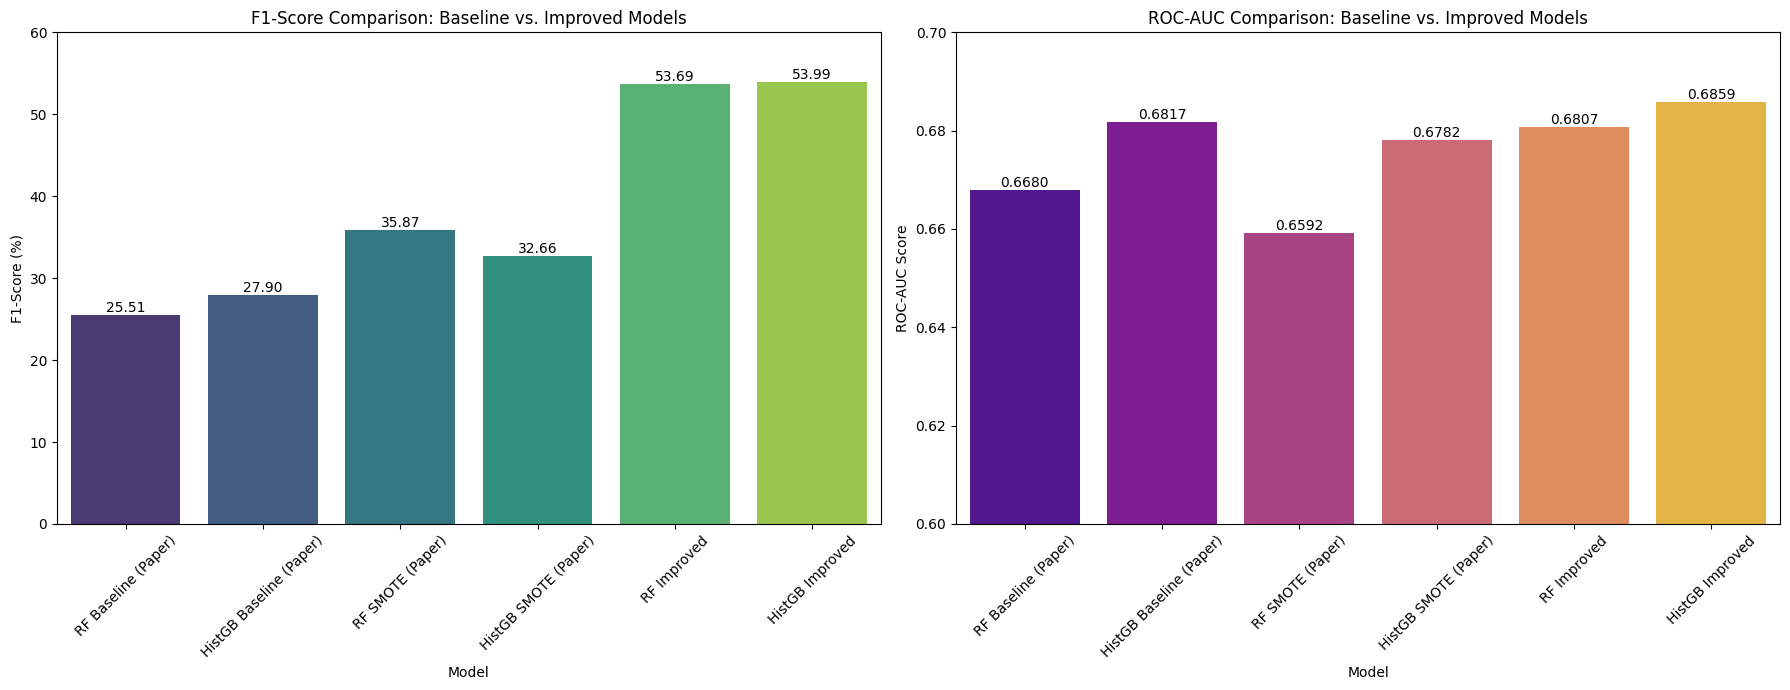

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# F1-Score Comparison
sns.barplot(x='Model', y='F1-Score', data=df_comparison, ax=axes[0], palette='viridis')
axes[0].set_title('F1-Score Comparison: Baseline vs. Improved Models')
axes[0].set_ylabel('F1-Score (%)')
axes[0].tick_params(axis='x', rotation=45)
axes[0].set_ylim(0, 60) # Adjust y-limit for better visualization
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%.2f')

# ROC-AUC Comparison
sns.barplot(x='Model', y='ROC-AUC', data=df_comparison, ax=axes[1], palette='plasma')
axes[1].set_title('ROC-AUC Comparison: Baseline vs. Improved Models')
axes[1].set_ylabel('ROC-AUC Score')
axes[1].tick_params(axis='x', rotation=45)
axes[1].set_ylim(0.6, 0.7)
for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%.4f')

plt.tight_layout()
plt.show()
